In [1]:
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import time

In [2]:
df = pd.read_csv('cleaned_autos.csv')
df

,dateCrawled,name,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,lastSeen,car_age,price_in_thousands
0,2016-03-17,GOLF 4 1 4 3TÜRER,test,hatchback,2001,manual,75.0,golf,150.0,6,gasoline,volkswagen,no,2016-03-17,2016-03-17,15.0,1.500000
1,2016-03-31,Skoda Fabia 1.4 TDI PD Classic,test,hatchback,2008,manual,69.0,fabia,90.0,7,diesel,skoda,no,2016-03-31,2016-04-06,8.0,3.600000
2,2016-04-04,BMW 316i e36 Limousine Bastlerfahrzeug Ex...,test,sedan,1995,manual,102.0,3er,150.0,10,gasoline,bmw,yes,2016-04-04,2016-04-06,21.0,0.650000
3,2016-04-01,Peugeot 206 CC 110 Platinum,test,cabrio,2004,manual,109.0,2_reihe,150.0,8,gasoline,peugeot,no,2016-04-01,2016-04-05,12.0,2.200000
4,2016-03-21,VW Derby Bj 80 Scheunenfund,test,sedan,1980,manual,50.0,andere,40.0,7,gasoline,volkswagen,no,2016-03-21,2016-03-25,36.0,6.204583
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260738,2016-03-19,turbo defekt,control,sedan,2004,manual,225.0,leon,150.0,5,gasoline,seat,yes,2016-03-19,2016-03-19,12.0,3.200000
260739,2016-03-27,Opel Zafira 1.6 Elegance TÜV 12/16,control,bus,2000,manual,0.0,zafira,150.0,3,gasoline,opel,no,2016-03-27,2016-03-29,16.0,1.150000
260740,2016-03-05,Smart smart leistungssteigerung 100ps,test,cabrio,2000,automatic,101.0,fortwo,125.0,3,gasoline,smart,no,2016-03-05,2016-03-11,16.0,1.199000
260741,2016-03-19,Volkswagen Multivan T4 TDI 7DC UY2,test,bus,1996,manual,102.0,transporter,150.0,3,diesel,volkswagen,no,2016-03-19,2016-04-07,20.0,9.200000


In [3]:
columns_to_drop = ['dateCrawled', 'name', 'abtest', 'monthOfRegistration', 
                   'dateCreated', 'lastSeen','model','yearOfRegistration']
df = df.drop(columns=columns_to_drop)


In [4]:
y = df['vehicleType']
x = df.drop(columns=['vehicleType'])
x_encoded = pd.get_dummies(x, drop_first=True)

In [5]:
rf_scout = RandomForestClassifier(n_estimators=50,random_state=42,n_jobs=-1)
rf_scout.fit(x_encoded, y)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [6]:
importance_df = pd.DataFrame({
    'Feature': x_encoded.columns,
    'Importance': rf_scout.feature_importances_
}).sort_values(by='Importance', ascending=False)

C:\Users\HFCS\AppData\Local\Temp\ipykernel_12612\3852104224.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='magma')


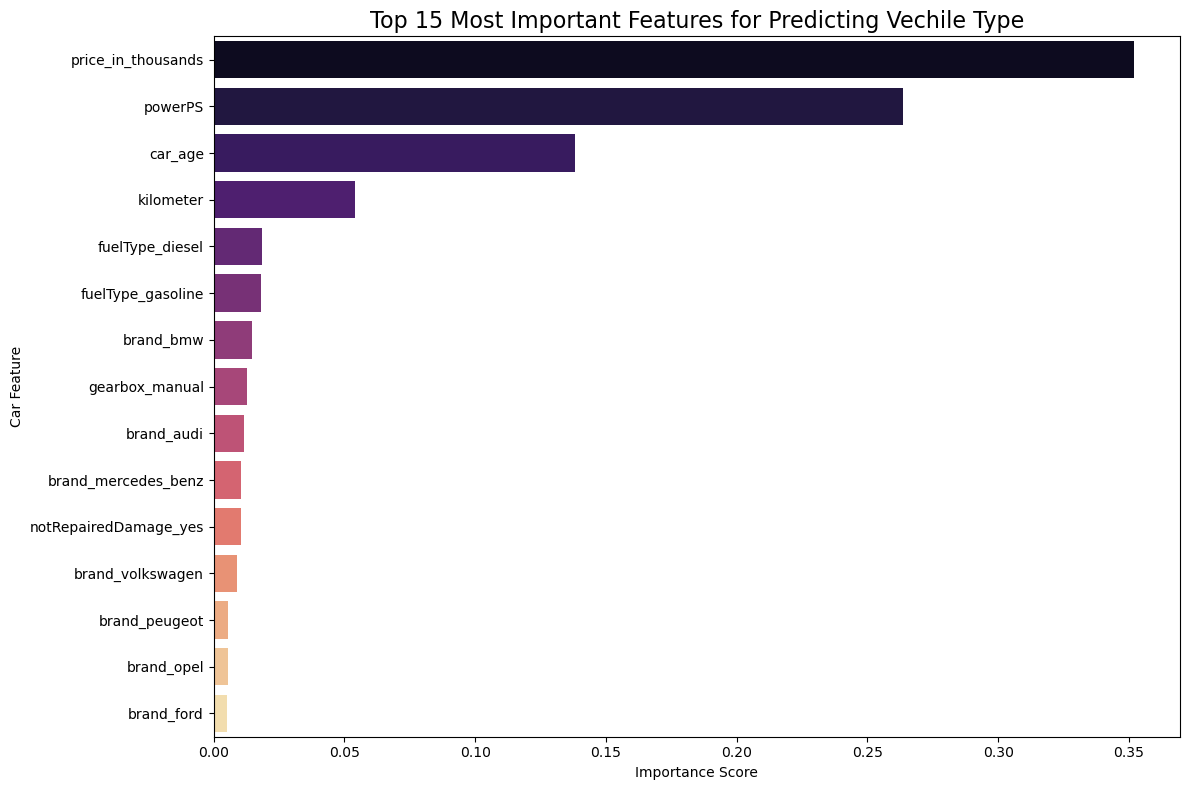

In [7]:
plt.figure(figsize=(12, 8))

sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='magma')

plt.title('Top 15 Most Important Features for Predicting Vechile Type', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Car Feature')
plt.tight_layout()
plt.show()

In [8]:
top_15_features = importance_df.head(15)['Feature'].tolist()
X_final = x_encoded[top_15_features]


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

In [10]:
start_time = time.time()
Mechanic_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
Mechanic_rf.fit(X_train, y_train)
print(f"Training time: {round(time.time() - start_time,1)} seconds")


Training time: 12.6 seconds


In [11]:
print("Report card for blind mechanic:")
predictions = Mechanic_rf.predict(X_test)
print(f"Overall AI Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%\n")
print(classification_report(y_test, predictions))

Report card for blind mechanic:
Overall AI Accuracy: 62.60%

               precision    recall  f1-score   support

          bus       0.57      0.54      0.55      4962
       cabrio       0.62      0.60      0.61      3708
        coupe       0.48      0.42      0.45      2913
    hatchback       0.78      0.82      0.80     11900
        other       0.20      0.08      0.12       375
        sedan       0.59      0.61      0.60     15257
station wagon       0.56      0.55      0.56     10669
          suv       0.63      0.62      0.63      2365

     accuracy                           0.63     52149
    macro avg       0.56      0.53      0.54     52149
 weighted avg       0.62      0.63      0.62     52149

